In [ ]:
#ARRANGER FM

In [1]:
import os
import subprocess

import mss
import win32gui
import numpy as np
from PIL import Image, ImageDraw

import vgamepad as vg
import time

In [2]:
# 1. Ścieżka do gry
game_path = r"E:\gry_laptop\Arranger"
#game_name = "Arranger"

#print(f"Uruchamiam grę: {game_name}")
#game = subprocess.Popen(os.path.join(game_path, game_name+".exe"), cwd=game_path)

In [3]:
class WindowCapture:
    def __init__(self, window_title):
        self.window_title = window_title
        self.hwnd = None

        self.left = 0
        self.top = 0
        self.width = 0
        self.height = 0
        self.update_window() #od razu formuje

    def update_window(self):
        self.hwnd = win32gui.FindWindow(None, self.window_title)
        if not self.hwnd:
            raise Exception("Window not found")

        l, t, r, b = win32gui.GetWindowRect(self.hwnd)

        self.left = l
        self.top = t
        self.width = r - l
        self.height = b - t

    def get_screenshot(self):
        with mss.mss() as sct:
            monitor = {
                "left": self.left+8,
                "top": self.top+31,
                "width": self.width-16,
                "height": self.height-39
            }

            img = sct.grab(monitor)
            #frame = np.array(img)[:,:,:4][:,:,:-1]  # BGRA
            frame = np.array(img)[:,:,:3][:,:,::-1]  # BGRA
            #mss.tools.to_png(img.rgb, img.size, output="window.png")
            return frame

In [4]:
class ArrangerGame():
    def __init__(self,game_path):
        game_name = "Arranger"
        print(f"Uruchamiam grę: {game_name}")
        g = subprocess.Popen(os.path.join(game_path, game_name+".exe"), cwd=game_path)

        self.gamepad = vg.VX360Gamepad()
        self.moveset = {"A":vg.XUSB_BUTTON.XUSB_GAMEPAD_A
                        ,"B":vg.XUSB_BUTTON.XUSB_GAMEPAD_B
                        ,"U":vg.XUSB_BUTTON.XUSB_GAMEPAD_DPAD_UP
                        ,"L":vg.XUSB_BUTTON.XUSB_GAMEPAD_DPAD_LEFT
                        ,"D":vg.XUSB_BUTTON.XUSB_GAMEPAD_DPAD_DOWN
                        ,"R":vg.XUSB_BUTTON.XUSB_GAMEPAD_DPAD_RIGHT
                        }
    
    def one_step(self,click,prep=None):
        if prep:
            time.sleep(prep) #czas na wyklikanie
        self.gamepad.press_button(button=self.moveset[click.upper()])
        self.gamepad.update()
        
        time.sleep(0.05)
        
        self.gamepad.release_button(button=self.moveset[click.upper()])
        self.gamepad.update()

        time.sleep(0.2)
        return
    
    def route(self,ll,w=0.01):
        print("!",ll)
        for m in list(ll):
            self.one_step(m)
        
        time.sleep(w)
        return

In [21]:
game = ArrangerGame(game_path)
game.one_step("A",25)
w = WindowCapture("Arranger")
game.route("ADDAADABA",25)
game.route("LLL",2)
#game.route("DLDRUULDLLDLUUUULDRDRDDDRURUUUULUUUULDDRDLLLUURDLUURDLDLLURUU",2) # my perfect

game.route("DLUULDRDRRDRUUUULDRUURDRURUUUULUUUULDDDRUURDLUURDLDLLULUU",2) #PC BETTER

print("ONE STEP AWAY")

Uruchamiam grę: Arranger
! ADDAADABA
! LLL
! DLUULDRDRRDRUUUULDRUURDRURUUUULUUUULDDDRUURDLUURDLDLLULUU
ONE STEP AWAY


In [10]:
len("DLDRUULDLLDLUUUULDRDRDDDRURUUUULUUUULDDRDLLLUURDLUURDLDLLURUU")

61

In [19]:
len("DLUULDRDRRDRUUUULDRUURDRURUUUULUUUULDDDRUURDLUURDLDLLULUU")

57

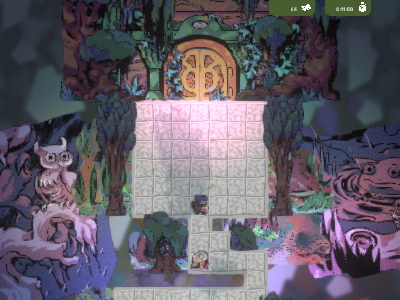

In [182]:
img_pil = Image.fromarray(frame, "RGB")
img_pil.save("Test_Graph.png")
#img_pil.show()
display(img_pil)

In [117]:
img_pil.save("Test_Graph.png")

In [133]:
from PIL import ImageDraw

draw = ImageDraw.Draw(img_pil)

tile_size = 20
line_width = 4
half = line_width // 2  # = 2

width, height = img_pil.size

# pionowe linie
for x in range(0, width + 1, tile_size):
    draw.rectangle(
        [x - half, 0, x + half - 1, height],
        fill=(0, 0, 0)
    )

# poziome linie
for y in range(0, height + 1, tile_size):
    draw.rectangle(
        [0, y - half, width, y + half - 1],
        fill=(0, 0, 0)
    )

draw.rectangle(
    [(130, 100), (270, 220)],
    outline=(0, 255, 0),  # zielony obrys
    width=2              # grubość linii
)

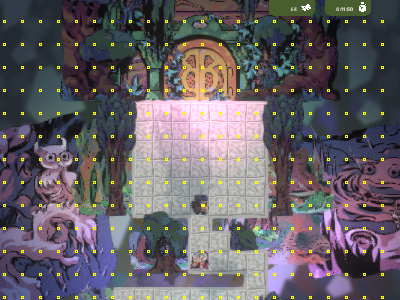

In [187]:
display(img_pil)

In [154]:
import cv2
hero = np.array(Image.open("static_hero.png"))[:,:,:3]
arr = np.array(img_pil)

img_gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
hero_gray = cv2.cvtColor(hero, cv2.COLOR_RGB2GRAY)


result = cv2.matchTemplate(img_gray, hero_gray, cv2.TM_CCOEFF_NORMED)
s0 = cv2.minMaxLoc(result)[-1]

In [183]:

draw = ImageDraw.Draw(img_pil)

cx, cy = 202,205 #[+ shape[0]//2, + shape[0]//2 +3]

half = 1  # 3x3 => od -1 do +1

draw.rectangle(
    [(cx - half, cy - half), (cx + half, cy + half)],
    outline=(255, 255, 0),
    fill=None
)

In [186]:
draw = ImageDraw.Draw(img_pil)

cx, cy = 202, 205
half = 1  # 3x3

width, height = img_pil.size

step_x = 18
step_y = 23

def draw_dot(x, y):
    draw.rectangle(
        [(x - half, y - half), (x + half, y + half)],
        outline=(255, 255, 0),
        fill=None
    )

# generujemy wszystkie przesunięcia od środka
# zakresy "ile kroków możemy zrobić"
nx_max = width // step_x + 2
ny_max = height // step_y + 2

for i in range(-nx_max, nx_max + 1):
    for j in range(-ny_max, ny_max + 1):
        x = cx + i * step_x
        y = cy + j * step_y

        # sprawdź czy w obrazie
        if 0 <= x < width and 0 <= y < height:
            draw_dot(x, y)

In [185]:
hero.shape

(23, 18, 3)

In [162]:
s0 = cv2.minMaxLoc(result)[-1]

In [173]:
s0[0]+hero.shape[0]//2,s0[1]+hero.shape[1]//2 #+2

(202.5, 202.0)

In [166]:
s0[0]+11,s0[1]+11

(191, 193)

In [160]:
hero_gray.shape

(23, 18)

In [161]:
20,

20.5

In [159]:
cv2.minMaxLoc(result)[-1]

(191, 193)

In [ ]:
min_val, max_val, min_loc, max_loc

In [143]:
type(img_pil)

PIL.Image.Image

In [136]:
from PIL import ImageDraw

draw = ImageDraw.Draw(img_pil)

# obszar prostokąta
x1, y1 = 130, 100
x2, y2 = 270, 220

cell = 20  # rozmiar kafelka

# pionowe linie
for x in range(x1, x2 + 1, cell):
    draw.line([(x, y1), (x, y2)], fill=(0, 255, 0), width=1)

# poziome linie
for y in range(y1, y2 + 1, cell):
    draw.line([(x1, y), (x2, y)], fill=(0, 255, 0), width=1)

# (opcjonalnie) obrys całego boxa
draw.rectangle([(x1, y1), (x2, y2)], outline=(255, 0, 0), width=2)

In [140]:
from PIL import ImageDraw

draw = ImageDraw.Draw(img_pil)

# prostokąt
x1, y1 = 130, 100
x2, y2 = 270, 220

cols = 7  # kolumny
rows = 6  # wiersze

cell_w = (x2 - x1) / cols   # 20
cell_h = (y2 - y1) / rows   # 20

# pionowe linie (kolumny)
for i in range(cols + 1):
    x = int(x1 + i * cell_w)
    draw.line([(x, y1), (x, y2)], fill=(0, 255, 0), width=1)

# poziome linie (wiersze)
for j in range(rows + 1):
    y = int(y1 + j * cell_h)
    draw.line([(x1, y), (x2, y)], fill=(0, 255, 0), width=1)

# obrys
draw.rectangle([(x1, y1), (x2, y2)], outline=(255, 0, 0), width=2)

In [ ]:
130x100 --  270x220

In [ ]:
6x7

In [ ]:
#około 20x20

400x300

120.000

In [ ]:
20x20  15x20

In [126]:
300**0.5

17.320508075688775

In [124]:
346*346

119716

In [123]:
18.6**2 

345.96000000000004

In [119]:
120000**0.25

18.612097182041992

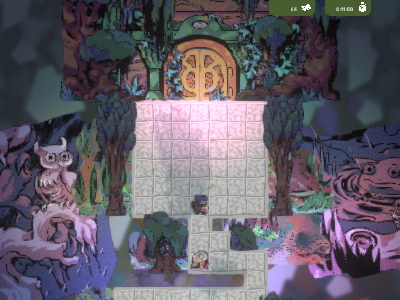

In [116]:
time.sleep(6)
#w=WindowCapture("Arranger")
frame = w.get_screenshot()

img_pil = Image.fromarray(frame, "RGB")
#img_pil.show()
display(img_pil)

In [ ]:
import mss
import win32gui

def get_window_rect(title):
    hwnd = win32gui.FindWindow(None, title)
    if not hwnd:
        raise Exception("Okno nie znalezione")

    rect = win32gui.GetWindowRect(hwnd)
    return rect  # (left, top, right, bottom)

window_title = "Notepad"  # np. tytuł okna
left, top, right, bottom = get_window_rect(window_title)

with mss.mss() as sct:
    monitor = {
        "left": left,
        "top": top,
        "width": right - left,
        "height": bottom - top
    }

    img = sct.grab(monitor)
